In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

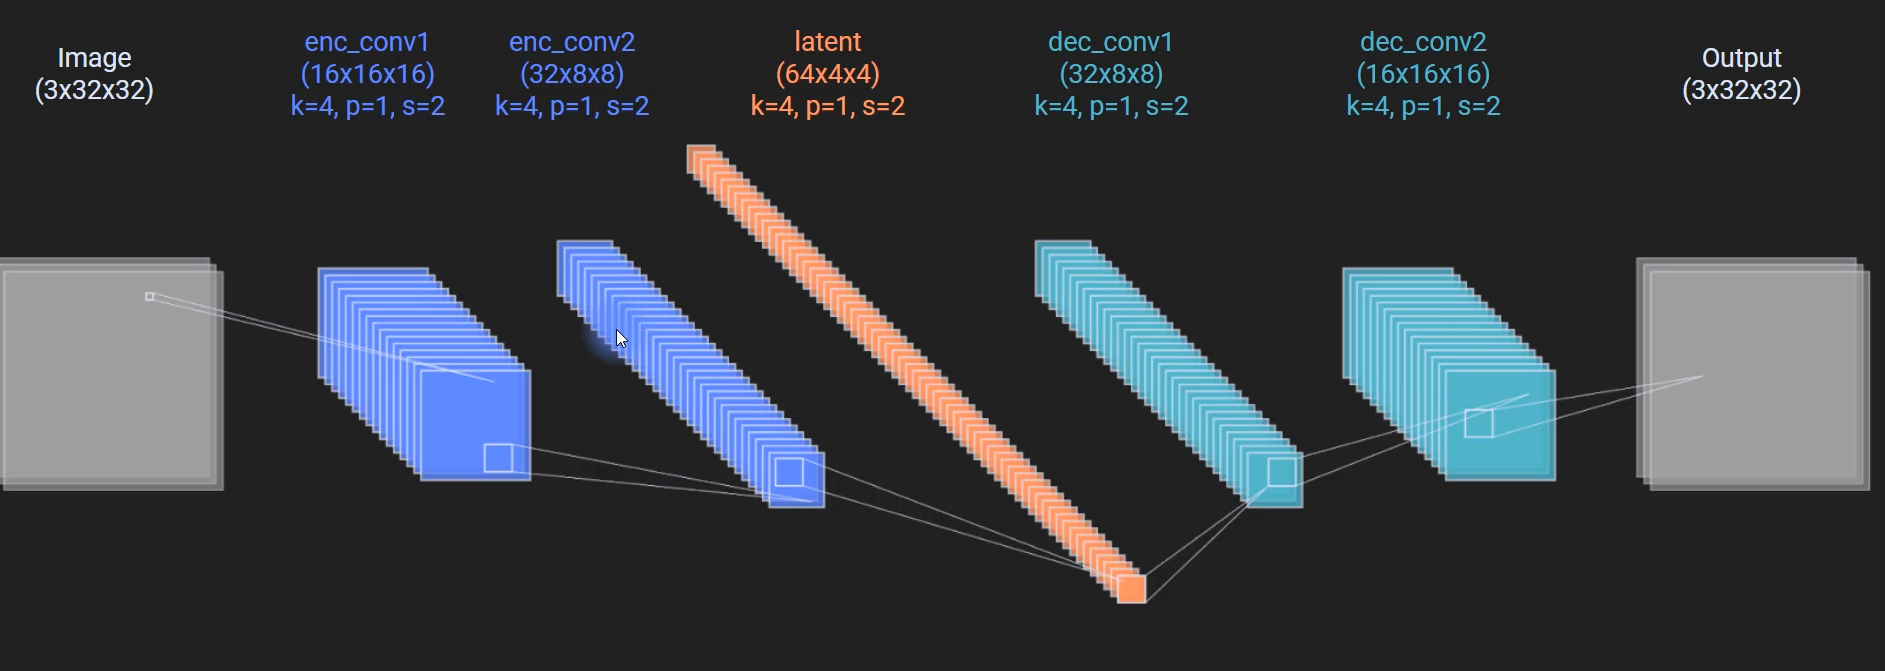

In [ ]:
transformer = transforms.Compose([
    transforms.ToTensor(), # convert PIL image to PyTorch tensor and scale pixel values to [0, 1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # normalize the pixel values to have mean 0 and std 1
    # If a pixel is 0 (minimum): (0 - 0.5) / 0.5 = -1
    # If a pixel is 1 (maximum): (1 - 0.5) / 0.5 = 1
])

data_train = datasets.CIFAR10(root='data', train=True, download=True, transform=transformer) 
data_test = datasets.CIFAR10(root='data', train=False, download=True, transform=transformer)    

# ToTensor(): This transform is lazy. It doesn't overwrite the original data in memory. 
# Instead, it only applies the conversion and scaling (-1 to 1) when the data is actually loaded (usually via a DataLoader or by indexing the dataset).
data_train.data.max()

d:\Pablo_Data\Documentos\VSCode\deep-learning\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


np.uint8(255)

In [5]:
data_val, data_test = train_test_split(data_test, test_size=0.5, random_state=42) # split the original test set into validation and test sets (50% each)

batch_size = 32
train_dataloader = DataLoader(data_train, batch_size=batch_size, shuffle=True, drop_last=True)
val_dataloader = DataLoader(data_val, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(data_test, batch_size=batch_size, shuffle=False)

# check out a sample
images, labels = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
images.min(), images.max() # check the range of pixel values (should be between -1 and 1 due to normalization)

Image batch shape: torch.Size([32, 3, 32, 32])
Label batch shape: torch.Size([32])


(tensor(-1.), tensor(1.))

In [11]:
class CIFAR10_AE(nn.Module):
    def __init__(self, deep=False):
        super().__init__()
        self.deep = deep  # store the flag to determine whether to use the deeper encoder-decoder

        self.encoder = nn.Sequential(
            # input size = (3, 32, 32) for CIFAR-10
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=4, stride=2, padding=1), # output size = np.floor((32 - 4 + 2*1) / 2) + 1 = 16
            nn.BatchNorm2d(num_features=16), # this is used to normalize the output of the convolutional layer, which can help with training stability and convergence
            nn.LeakyReLU(),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=4, stride=2, padding=1), # output size = np.floor((16 - 4 + 2*1) / 2) + 1 = 8
            nn.BatchNorm2d(num_features=32), 
            nn.LeakyReLU(),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1), # output size = np.floor((8 - 4 + 2*1) / 2) + 1 = 4
            nn.BatchNorm2d(num_features=64), 
            nn.LeakyReLU(),
        )

        self.bottleneck = nn.Sequential(
            # start encoder-decoder part
            nn.Flatten(),
            nn.Linear(64*4*4, 128), # this is the bottleneck layer where we compress the information into a lower-dimensional representation (128 in this case)
            nn.LeakyReLU(),

            # start decoder part
            nn.Linear(128, 64*4*4), # this is the layer that expands the compressed representation back to the original size before the decoder
            nn.LeakyReLU(),
            nn.Unflatten(1, (64, 4, 4)) 
        ) if deep else None        # only instantiate if needed

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, stride=2, padding=1), # output size = (4 - 1) * 2 + 4 - 2*1 = 8
            nn.BatchNorm2d(num_features=32),
            nn.LeakyReLU(),

            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=4, stride=2, padding=1), # output size = (8 - 1) * 2 + 4 - 2*1 = 16
            nn.BatchNorm2d(num_features=16), 
            nn.LeakyReLU(),

            nn.ConvTranspose2d(in_channels=16, out_channels=3, kernel_size=4, stride=2, padding=1), # output size = (16 - 1) * 2 + 4 - 2*1 = 32
            # do not add BN or activation function here because we want the output to be in the range [-1, 1] to match the normalized input pixel values
            nn.Tanh() # use Tanh activation to ensure the output pixel values are in the range [-1, 1]
        )

    def forward(self, x):

        x = self.encoder(x)
        if self.deep:
            x = self.bottleneck(x)
        x = self.decoder(x)
        
        return x
    
model = CIFAR10_AE(deep=False)
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 16, 16]             784
       BatchNorm2d-2           [-1, 16, 16, 16]              32
         LeakyReLU-3           [-1, 16, 16, 16]               0
            Conv2d-4             [-1, 32, 8, 8]           8,224
       BatchNorm2d-5             [-1, 32, 8, 8]              64
         LeakyReLU-6             [-1, 32, 8, 8]               0
            Conv2d-7             [-1, 64, 4, 4]          32,832
       BatchNorm2d-8             [-1, 64, 4, 4]             128
         LeakyReLU-9             [-1, 64, 4, 4]               0
  ConvTranspose2d-10             [-1, 32, 8, 8]          32,800
      BatchNorm2d-11             [-1, 32, 8, 8]              64
        LeakyReLU-12             [-1, 32, 8, 8]               0
  ConvTranspose2d-13           [-1, 16, 16, 16]           8,208
      BatchNorm2d-14           [-1, 16,

In [14]:
# test one forward pass to see the print statements in action
model = CIFAR10_AE()
loss_fn = nn.MSELoss() # for autoencoders, we typically use MSE loss to measure the difference between the input and the reconstructed output
images, labels = next(iter(train_dataloader))
output = model(images)
loss = loss_fn(output, images)
print(f"Input shape: {images.shape}")
print(f"Output shape: {output.shape}")
print(f"Loss: {loss.item()}")

Input shape: torch.Size([32, 3, 32, 32])
Output shape: torch.Size([32, 3, 32, 32])
Loss: 0.443487286567688


In [17]:
def train_one_epoch(model: torch.nn.Module,
                    train_dataloader: torch.utils.data.DataLoader,
                    loss_fn: torch.nn.Module,
                    optimizer: torch.optim.Optimizer,
                    ):
    model.train()
    train_loss = 0.0

    for batch, (X, y) in enumerate(train_dataloader):
        # Forward pass
        outputs = model(X)
        loss = loss_fn(outputs, X)  # for autoencoders, the target is the input itself

        # Update training loss
        train_loss += loss.item()

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          ):

    train_losses_epochs = []
    val_losses_epochs = []

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_dataloader, loss_fn, optimizer)

        # Calculate average training loss for the epoch
        avg_train_loss = train_loss / len(train_dataloader)
        train_losses_epochs.append(avg_train_loss)

        # Evaluate on the validation set
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for X, y in val_dataloader:
                outputs = model(X)
                loss = loss_fn(outputs, X)

                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)
        val_losses_epochs.append(avg_val_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Train Loss: {avg_train_loss:.4f}, "
            f"Val Loss: {avg_val_loss:.4f}"
        )

    return train_losses_epochs, val_losses_epochs

In [19]:
loss_fn = nn.MSELoss()
epochs = 10

model = CIFAR10_AE(deep=False)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
train_loss, val_loss = train(model, train_dataloader, val_dataloader, loss_fn, optimizer, epochs)

Epoch [1/10], Train Loss: 0.0294, Val Loss: 0.0131
Epoch [2/10], Train Loss: 0.0144, Val Loss: 0.0107
Epoch [3/10], Train Loss: 0.0118, Val Loss: 0.0126
Epoch [4/10], Train Loss: 0.0102, Val Loss: 0.0082
Epoch [5/10], Train Loss: 0.0092, Val Loss: 0.0093
Epoch [6/10], Train Loss: 0.0086, Val Loss: 0.0067
Epoch [7/10], Train Loss: 0.0081, Val Loss: 0.0062
Epoch [8/10], Train Loss: 0.0077, Val Loss: 0.0057
Epoch [9/10], Train Loss: 0.0075, Val Loss: 0.0072
Epoch [10/10], Train Loss: 0.0072, Val Loss: 0.0058


In [20]:
# compute test loss
model.eval()
test_loss = 0.0
with torch.no_grad():
    for X, y in test_dataloader:
        outputs = model(X)
        loss = loss_fn(outputs, X)
        test_loss += loss.item()
avg_test_loss = test_loss / len(test_dataloader)
print(f"Test Loss: {avg_test_loss:.4f}")

Test Loss: 0.0057


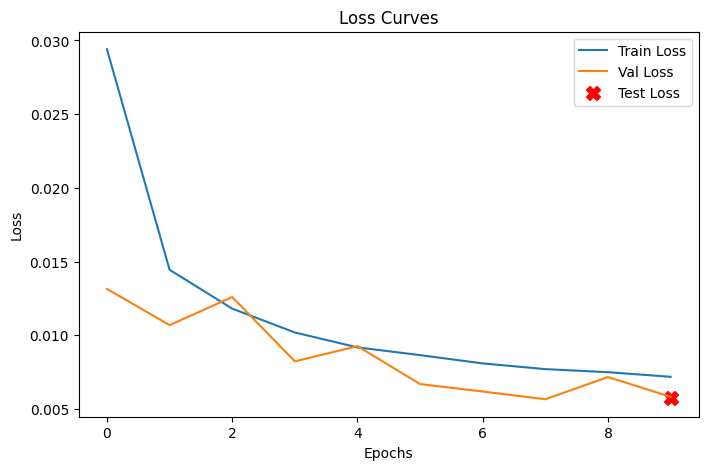

In [22]:
# plot loss and accuracy curves
plt.subplots(nrows=1, ncols=1, figsize=(8, 5))
plt.subplot(1, 1, 1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.scatter(epochs-1, avg_test_loss, label="Test Loss", color="red", marker="X", s=100)
plt.title("Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

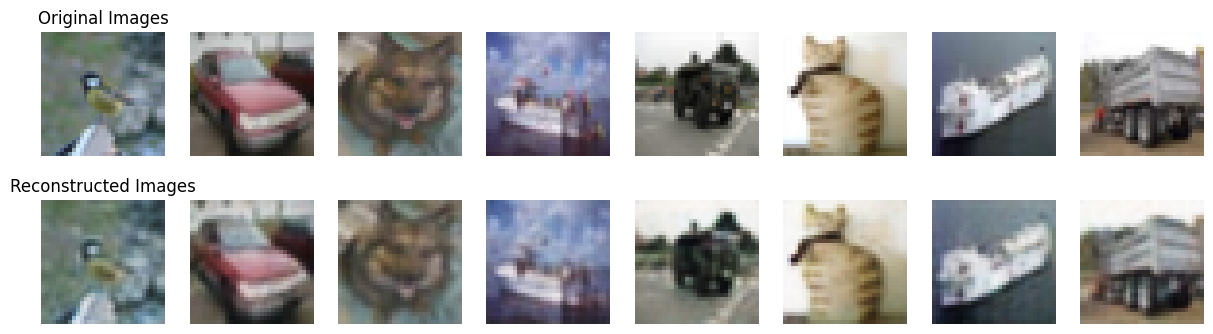

In [23]:
# plot some original and reconstructed images
model.eval()
with torch.no_grad():
    for X, y in test_dataloader:
        outputs = model(X)
        break  # just take the first batch for visualization
    
fig, axes = plt.subplots(nrows=2, ncols=8, figsize=(15, 4))
for i in range(8):
    # original images
    ax = axes[0, i]
    img = X[i].permute(1, 2, 0).numpy()  # convert from (C, H, W) to (H, W, C) and to numpy array
    img = (img * 0.5) + 0.5  # unnormalize the pixel values back to [0, 1] for visualization
    ax.imshow(img)
    ax.axis("off")
    if i == 0:
        ax.set_title("Original Images")

    # reconstructed images
    ax = axes[1, i]
    recon_img = outputs[i].permute(1, 2, 0).numpy()  # convert from (C, H, W) to (H, W, C) and to numpy array
    recon_img = (recon_img * 0.5) + 0.5  # unnormalize the pixel values back to [0, 1] for visualization
    ax.imshow(recon_img)
    ax.axis("off")
    if i == 0:
        ax.set_title("Reconstructed Images")